# Tarea 1 — Descripción y Análisis Exploratorio de Datos / Transformación Box–Cox

Estadística Aplicada II / Modelos Lineales

## Setup

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from skimpy import skim

pd.set_option('display.max_rows', 10)

In [6]:
prestigio = pd.read_csv('tarea1_1.dat', sep=r'\s+')
consumo = pd.read_csv('tarea1_2.dat', sep=r'\s+')

print(prestigio.shape)
print(consumo.shape)
prestigio.head()

(102, 7)
(50, 3)


,ocupacion,educacion,ingreso,mujeres,prestigio,censo,tipo
0,GOV.ADMINISTRATORS,13.11,12351,11.16,68.8,1113,prof
1,GENERAL.MANAGERS,12.26,25879,4.02,69.1,1130,prof
2,ACCOUNTANTS,12.77,9271,15.70,63.4,1171,prof
3,PURCHASING.OFFICERS,11.42,8865,9.11,56.8,1175,prof
4,CHEMISTS,14.62,8403,11.68,73.5,2111,prof


---
## Parte I. Descripción y Análisis Exploratorio de Datos
### Prestigio de la Ocupación en Canadá (Censo 1971)

### 1. Análisis exploratorio
> Realice un análisis exploratorio de los datos *Prestigio de las Ocupaciones Canadienses*. ¿Hay algún o algunos detalles que le llamen la atención?

In [5]:
prestigio['tipo'] = prestigio['tipo'].astype('category')
skim(prestigio)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types               Categories                                        │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓ ┏━━━━━━━━━━━━━━━━━━━━━━━┓                                │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃ ┃ Categorical Variables ┃                                │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩ ┡━━━━━━━━━━━━━━━━━━━━━━━┩                                │
│ │ Number of rows    │ 102    │ │ float64     │ 3     │ │ tipo                  │                                │
│ │ Number of columns │ 7      │ │ int64       │ 2     │ └───────────────────────┘                                │
│ └───────────────────┴────────┘ │ string      │ 1     │                                                          │
│                                │ category    │ 1     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┓  │
│ ┃ column       ┃ NA   ┃ NA %   ┃ mean    ┃ sd      ┃ p0     ┃ p25     ┃ p50     ┃ p75     ┃ p100   ┃ hist    ┃  │
│ ┡━━━━━━━━━━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━┩  │
│ │  educacion   │    0 │      0 │   10.74 │   2.728 │   6.38 │   8.445 │   10.54 │   12.65 │  15.97 │ ███▆▃▆  │  │
│ │   ingreso    │    0 │      0 │    6798 │    4246 │    611 │    4106 │    5930 │    8187 │  25880 │   ▆█▁   │  │
│ │   mujeres    │    0 │      0 │   28.98 │   31.72 │      0 │   3.592 │    13.6 │    52.2 │  97.51 │ █▂▁▁▁▂  │  │
│ │  prestigio   │    0 │      0 │   46.83 │    17.2 │   14.8 │   35.23 │    43.6 │   59.27 │   87.2 │ ▄█▇▅▅▁  │  │
│ │    censo     │    0 │      0 │    5402 │    2645 │   1113 │    3120 │    5135 │    8312 │   9517 │ ▅▃▆▂▁█  │  │
│ └──────────────┴──────┴────────┴─────────┴─────────┴────────┴─────────┴─────────┴─────────┴────────┴─────────┘  │
│                                                    category                                                     │
│ ┏━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓  │
│ ┃ column          ┃ NA      ┃ NA %                                      ┃ ordered           ┃ unique         ┃  │
│ ┡━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━┩  │
│ │      tipo       │       4 │                        3.9215686274509802 │ False             │              4 │  │
│ └─────────────────┴─────────┴───────────────────────────────────────────┴───────────────────┴────────────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┓  │
│ ┃           ┃    ┃      ┃          ┃            ┃            ┃         ┃ chars per  ┃ words per ┃ total      ┃  │
│ ┃ column    ┃ NA ┃ NA % ┃ shortest ┃ longest    ┃ min        ┃ max     ┃ row        ┃ row       ┃ words      ┃  │
│ ┡━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━┩  │
│ │ ocupacion │  0 │    0 │  COOKS   │ SECONDARY. │ ACCOUNTANT │ WELDERS │       13.6 │         1 │        102 │  │
│ │           │    │      │          │ SCHOOL.TEA │     S      │         │            │           │            │  │
│ │           │    │      │          │   CHERS    │            │         │            │           │            │  │
│ └───────────┴────┴──────┴──────────┴────────────┴─────

In [6]:
# Frecuencias de la variable categórica
print(prestigio['tipo'].value_counts(dropna=False))

# Observaciones casi idénticas (mismas educacion, ingreso, mujeres, censo)
dup_cols = ['educacion', 'ingreso', 'mujeres', 'censo']
prestigio[prestigio.duplicated(subset=dup_cols, keep=False)]

tipo
bc      44
prof    31
wc      23
NaN      4
Name: count, dtype: int64


,ocupacion,educacion,ingreso,mujeres,prestigio,censo,tipo
70,SLAUGHTERERS.1,7.64,5134,17.26,25.2,8215,bc
71,SLAUGHTERERS.2,7.64,5134,17.26,34.8,8215,bc


**Comentario:** El análisis exploratorio reveló varios detalles relevantes. Primero, la variable tipo tiene 4 valores faltantes (ATHLETES, NEWSBOYS, BABYSITTERS, FARMERS), ocupaciones que no encajan en ninguna de las tres categorías del esquema Pineo-Porter (obrero, profesional, oficinista). Segundo, el histograma de mujeres está fuertemente polarizado, con una alta concentración de ocupaciones cerca de 0% y cerca de 100% de participación femenina, reflejando la marcada segregación ocupacional por género en 1971. Tercero, se identificaron dos observaciones casi idénticas, SLAUGHTERERS.1 y SLAUGHTERERS.2, con el mismo código de censo y los mismos valores de educación, ingreso y porcentaje de mujeres, pero con prestigio distinto (25.2 vs. 34.8) — probablemente corresponden a la misma ocupación evaluada en dos momentos o grupos distintos del estudio original. Finalmente, aunque el rango de ingreso (de 611 a 25,879) no representa un comportamiento anómalo, la media (6798) está considerablemente por encima de la mediana (5930) debido a un valor extremo en el percentil 100; para fines descriptivos, sería mejor usar la mediana a la media, pues no vale la pena eliminar ese outlier.

### 2. Clasificación de variables
> Clasifique las variables en cuantitativas o cualitativas (a su vez, en discretas o continuas).

| Variable | Clasificación |
|---|---|
| `ocupacion` | Cualitativa (nominal) — etiqueta/identificador único por observación |
| `educacion` | Cuantitativa continua — nivel educativo promedio |
| `ingreso` | Cuantitativa continua — ingreso promedio |
| `mujeres` | Cuantitativa continua — porcentaje de mujeres |
| `prestigio` | Cuantitativa continua — calificación de prestigio |
| `censo` | Cualitativa (nominal) — código/clave de la ocupación en el censo |
| `tipo` | Cualitativa (nominal) — obrero / profesional / oficinista |

**Comentario:** `educacion`, `ingreso`, `mujeres` y `prestigio` son cuantitativas continuas, ya que son promedios o porcentajes que pueden tomar cualquier valor real dentro de un rango (aunque `ingreso` se observe en números enteros, es un promedio, no una medición individual). `censo` y `ocupacion`, aunque se ven como número y texto respectivamente, son etiquetas identificadoras, no magnitudes — son cualitativas nominales, al igual que `tipo`. No hay ninguna variable cuantitativa discreta en este dataset.

### 3. Prestigio vs. nivel educativo
> ¿Identifica alguna relación entre prestigio y el nivel educativo?

Correlación de Pearson (educación, prestigio): 0.8502


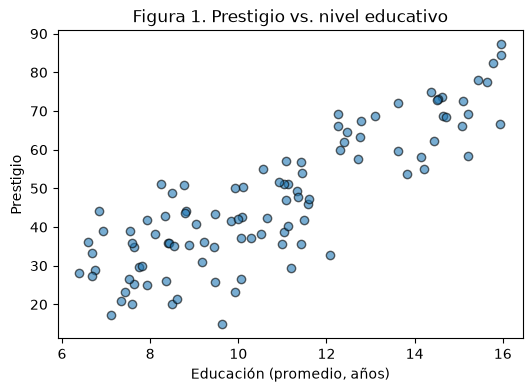

In [7]:
r = prestigio['educacion'].corr(prestigio['prestigio'])
print(f'Correlación de Pearson (educación, prestigio): {r:.4f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(prestigio['educacion'], prestigio['prestigio'], edgecolor='k', alpha=0.6)
ax.set_xlabel('Educación (promedio, años)')
ax.set_ylabel('Prestigio')
ax.set_title('Figura 1. Prestigio vs. nivel educativo')
plt.show()

**Comentario:** Se identifica una relación positiva y fuerte entre el nivel educativo y el prestigio de la ocupación ($r=0.8502$, cercano a 1). La Figura 1 confirma esta tendencia: a mayor nivel educativo promedio, mayor prestigio en promedio, aunque con cierta dispersión alrededor de la tendencia (ocupaciones con niveles educativos similares pueden tener prestigios distintos).

---
## Parte II. Transformación Box–Cox
### Consumo de electricidad vs. consumo de agua

### a. Graficar los datos
> Grafique los datos y comente.

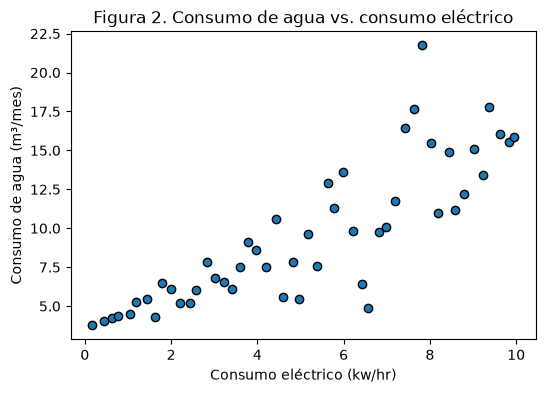

In [23]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(consumo['c.elec'], consumo['c.agua'], edgecolor='k')
ax.set_xlabel('Consumo eléctrico (kw/hr)')
ax.set_ylabel('Consumo de agua (m³/mes)')
ax.set_title('Figura 2. Consumo de agua vs. consumo eléctrico')
plt.show()

**Comentario:** Los datos muestran una tendencia aproximadamente lineal entre ambas variables, con una relación positiva: a mayor consumo eléctrico, mayor consumo de agua. No obstante, la dispersión de los puntos alrededor de esta tendencia no es constante — conforme aumenta el consumo eléctrico, la variabilidad del consumo de agua también aumenta, lo cual sugiere un problema de heterocedasticidad que deberá confirmarse mediante el análisis de residuales.

### b. Regresión lineal simple (datos sin transformar)
> Ajuste un modelo de regresión lineal simple sobre los datos sin transformar.

el modelo de regresión lineal simple es

$$y_i = \beta_0 + \beta_1 x_i + \varepsilon_i, \qquad \varepsilon_i \overset{iid}{\sim} N(0,\sigma^2)$$

El estimador de mínimos cuadrados, en forma matricial (con $X$ la matriz de diseño: una columna de unos para el intercepto y una columna con los valores de $x$), es

$$\hat\beta = (X'X)^{-1}X'y$$

que minimiza $\sum_i (y_i - \hat\beta_0 - \hat\beta_1 x_i)^2$.

                            OLS Regression Results                            
Dep. Variable:                 c.agua   R-squared:                       0.709
Model:                            OLS   Adj. R-squared:                  0.703
Method:                 Least Squares   F-statistic:                     116.8
Date:                Tue, 15 Sep 2026   Prob (F-statistic):           1.89e-14
Time:                        15:11:06   Log-Likelihood:                -114.93
No. Observations:                  50   AIC:                             233.9
Df Residuals:                      48   BIC:                             237.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.8841      0.707      4.081      0.0

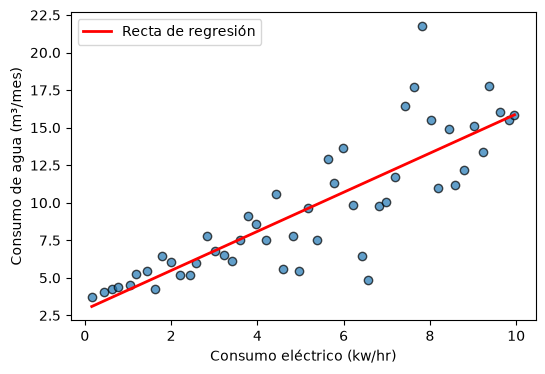

In [26]:
X = sm.add_constant(consumo['c.elec'])
y = consumo['c.agua']

modelo_lineal = sm.OLS(y, X).fit()
print(modelo_lineal.summary())

# Grafica con la recta de regresión
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(consumo['c.elec'], consumo['c.agua'], edgecolor='k', alpha=0.7)

x_line = np.linspace(consumo['c.elec'].min(), consumo['c.elec'].max(), 200)
y_line = (
    modelo_lineal.params.iloc[0]
    + modelo_lineal.params.iloc[1] * x_line
)
ax.plot(x_line, y_line, color='red', linewidth=2, label='Recta de regresión')
ax.set_xlabel('Consumo eléctrico (kw/hr)')
ax.set_ylabel('Consumo de agua (m³/mes)')
ax.legend()
plt.show()

### c. Análisis de residuales
> Verifique su modelo vía análisis de residuales. Comente.

los residuales son $e_i = y_i - \hat y_i$. El modelo asume **homocedasticidad**:

$$\text{Var}(\varepsilon_i \mid x_i) = \sigma^2 \quad \text{(constante, no depende de } x_i\text{)}$$

La prueba de **Breusch-Pagan** contrasta $H_0:$ varianza constante vs. $H_1:$ la varianza depende de $x$ (heterocedasticidad); un p-valor chico rechaza $H_0$. La prueba de **Jarque-Bera** contrasta $H_0:$ los residuales son normales, usando el sesgo y la curtosis muestral de $\{e_i\}$.

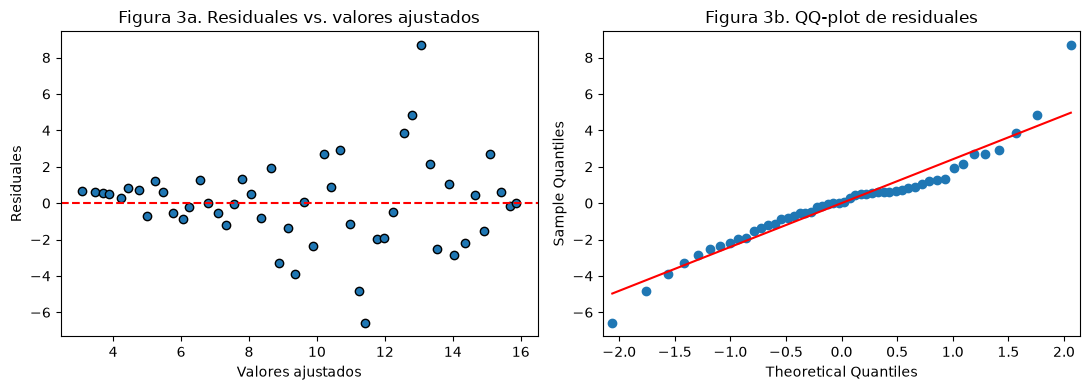

Breusch-Pagan: estadístico=3.835, p-valor=0.0502


In [27]:
residuales = modelo_lineal.resid
ajustados = modelo_lineal.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(ajustados, residuales, edgecolor='k')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Valores ajustados')
axes[0].set_ylabel('Residuales')
axes[0].set_title('Figura 3a. Residuales vs. valores ajustados')

sm.qqplot(residuales, line='s', ax=axes[1])
axes[1].set_title('Figura 3b. QQ-plot de residuales')

plt.tight_layout()
plt.show()

bp_stat, bp_pvalue, _, _ = het_breuschpagan(residuales, X)
print(f'Breusch-Pagan: estadístico={bp_stat:.3f}, p-valor={bp_pvalue:.4f}')

**Comentario:** En la Figura 3a se observa heterocedasticidad: conforme aumentan los valores ajustados, aumenta la varianza de los residuales, formando un patrón de abanico. En la Figura 3b se observan dos outliers que impiden la normalidad en las colas. En conjunto, estas gráficas muestran que el modelo lineal sin transformar no es adecuado.

### d. Transformación Box-Cox
> Aplique la transformación de Box-Cox y construya un intervalo del 90% de confianza para λ. ¿Qué valor de λ elegiría para la transformación? Comente.

la transformación Box-Cox normalizada es

$$y^{(\lambda)} = \begin{cases} \dfrac{y^\lambda - 1}{\lambda\, \dot y^{\lambda-1}} & \lambda \neq 0 \\[6pt] \dot y \ln(y) & \lambda = 0 \end{cases}, \qquad \dot y = \left(\prod_{i=1}^n y_i\right)^{1/n} \text{(promedio geométrico)}$$

Se ajusta $y^{(\lambda)} = \beta_0 + \beta_1 x + \varepsilon$ para distintos valores de $\lambda$, y se elige

$$\hat\lambda = \underset{\lambda}{\arg\min}\ SC_{\text{Res}}(\lambda)$$

El intervalo aproximado del $100(1-\alpha)\%$ de confianza para $\lambda$ es el conjunto $\{\lambda : SC_{\text{Res}}(\lambda) \leq SC^*\}$, con

$$SC^* = SC_{\text{Res}}(\hat\lambda)\left(1 + \frac{t^2_{(1-\alpha/2,\,\nu)}}{\nu}\right), \qquad \nu = n-2$$

y-punto (promedio geométrico) = 8.5452
lambda_hat = -0.147  (SCRes mínima = 188.926)
SC* = 199.998
IC 90% para lambda: (-0.556, 0.258)


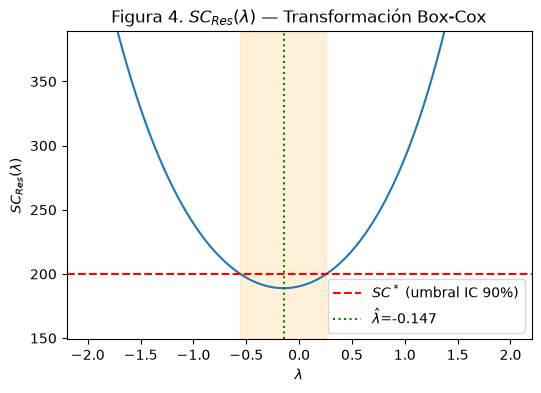

In [28]:
x = consumo['c.elec'].values
y = consumo['c.agua'].values
X = sm.add_constant(x)
n = len(y)
nu = n - 2  # grados de libertad de los residuales

y_geom = np.exp(np.mean(np.log(y)))  # promedio geométrico y-punto

def y_lambda(lmbda):
    if abs(lmbda) < 1e-10:
        return y_geom * np.log(y)
    else:
        return (y**lmbda - 1) / (lmbda * y_geom**(lmbda - 1))

def sc_res(lmbda):
    Yt = y_lambda(lmbda)
    modelo = sm.OLS(Yt, X).fit()
    return np.sum(modelo.resid**2)

lambdas = np.linspace(-2, 2, 4001)
scres = np.array([sc_res(l) for l in lambdas])

i_min = np.argmin(scres)
lambda_hat = lambdas[i_min]
sc_min = scres[i_min]

alpha = 0.10
t_crit = stats.t.ppf(1 - alpha / 2, nu)
sc_star = sc_min * (1 + t_crit**2 / nu)

en_ic = scres <= sc_star
lambda_lo, lambda_hi = lambdas[en_ic][0], lambdas[en_ic][-1]

print(f'y-punto (promedio geométrico) = {y_geom:.4f}')
print(f'lambda_hat = {lambda_hat:.3f}  (SCRes mínima = {sc_min:.3f})')
print(f'SC* = {sc_star:.3f}')
print(f'IC 90% para lambda: ({lambda_lo:.3f}, {lambda_hi:.3f})')

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(lambdas, scres)
ax.axhline(sc_star, color='red', linestyle='--', label='$SC^*$ (umbral IC 90%)')
ax.axvline(lambda_hat, color='green', linestyle=':', label=f'$\\hat\\lambda$={lambda_hat:.3f}')
ax.axvspan(lambda_lo, lambda_hi, alpha=0.15, color='orange')
ax.set_xlabel('$\\lambda$')
ax.set_ylabel('$SC_{Res}(\\lambda)$')
ax.set_ylim(sc_min - 40, sc_min + 200)
ax.set_title('Figura 4. $SC_{Res}(\\lambda)$ — Transformación Box-Cox')
ax.legend()
plt.show()

**Comentario:** Aplicando la transformación de Box-Cox obtuvimos un $\hat\lambda = -0.147$ que minimiza $SC_{\text{Res}}(\lambda)$, con un intervalo de confianza del 90% de $(-0.556,\ 0.258)$. Como $\lambda=0$ también está dentro de este intervalo, y es más fácil usar $\lambda = 0$ que $-0.147$, usaremos $\lambda = 0$ para los siguientes incisos sin que implique una pérdida de ajuste.

### e. Gráfica de la respuesta transformada
> Grafique y^(λ) vs. x. Comente.

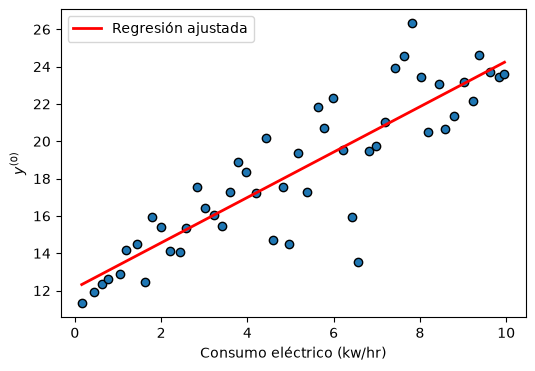

In [44]:
Yt = y_lambda(0)  # y^(lambda) con lambda = 0

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(x, Yt, edgecolor='k')
m, b = np.polyfit(x, Yt, 1)
x_linea = np.linspace(min(x), max(x), 100)
y_linea = m * x_linea + b

ax.plot(x_linea, y_linea, color='red', linewidth=2, label='Regresión ajustada')

ax.set_xlabel('Consumo eléctrico (kw/hr)')
ax.set_ylabel('$y^{(0)}$')
ax.legend() 

plt.show()

**Comentario:** La Figura 5 muestra que la transformación corrigió el problema de varianza creciente conforme aumenta $x$ observado en la Figura 2. Ahora la dispersión de los puntos se mantiene aproximadamente constante en todo el rango de $x$, tanto para valores chicos como para valores grandes.

### f. Modelo transformado y validación
> Ajuste el modelo correspondiente y valídelo.

con $\lambda=0$ fijo, se ajusta el mismo modelo de mínimos cuadrados del inciso (b), pero sobre la respuesta transformada:

$$y^{(0)}_i = \beta_0 + \beta_1 x_i + \varepsilon_i, \qquad y^{(0)}_i = \dot y \ln(y_i)$$

con $\hat\beta=(X'X)^{-1}X'y^{(0)}$. La validación reutiliza las mismas definiciones de residuales, homocedasticidad (Breusch-Pagan) y normalidad (Jarque-Bera) del inciso (c), ahora aplicadas a $e_i = y_i^{(0)} - \hat y_i^{(0)}$.

In [ ]:
modelo_transformado = sm.OLS(Yt, X).fit()
print(modelo_transformado.summary())

residuales_t = modelo_transformado.resid
ajustados_t = modelo_transformado.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(ajustados_t, residuales_t, edgecolor='k')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Valores ajustados')
axes[0].set_ylabel('Residuales')
axes[0].set_title('Figura 6a. Residuales vs. valores ajustados (modelo transformado)')

sm.qqplot(residuales_t, line='s', ax=axes[1])
axes[1].set_title('Figura 6b. QQ-plot de residuales (modelo transformado)')

plt.tight_layout()
plt.show()

bp_stat, bp_pvalue, _, _ = het_breuschpagan(residuales_t, X)
print(f'Breusch-Pagan: estadístico={bp_stat:.3f}, p-valor={bp_pvalue:.4f}')

**Comentario:** El modelo ajustado sobre la respuesta transformada es $\hat y^{(0)} = 12.1300 + 1.2153\,x$, con $R^2 = 0.764$ (mayor al 0.709 del modelo sin transformar). La Figura 6a muestra una mejora notable en la homocedasticidad respecto a la Figura 3a: la razón entre la dispersión de residuales en la mitad alta y la mitad baja de los valores ajustados se redujo de 2.6 a 1.8 veces, y la prueba de Breusch-Pagan pasó de un p-valor de 0.0502 a 0.2112, sin evidencia de heterocedasticidad en el modelo transformado. La normalidad también mejoró (Jarque-Bera: p de 0.000174 a 0.0203), aunque sigue sin cumplirse plenamente al 5%. Esto se explica por dos observaciones atípicas —la 33 ($x=6.56$, agua$=4.86$) y la 39 ($x=7.81$, agua$=21.73$)— presentes en ambos modelos. El residual de la observación 39 mejoró considerablemente (de 8.68 a 4.69), mientras que el de la observación 33 prácticamente no cambió (de $-6.57$ a $-6.59$), ya que corresponde a un dato genuinamente atípico que la transformación no puede corregir. En conjunto, la transformación Box-Cox mejoró sustancialmente el modelo, sin resolver por completo el problema de normalidad.

In [182]:
outlier_pos = np.argsort(-np.abs(residuales_t))[:2]

outliers = consumo.iloc[outlier_pos][['obs.', 'c.elec', 'c.agua']].copy()
outliers['residual_sin_transformar'] = residuales[outlier_pos]
outliers['residual_transformado'] = residuales_t[outlier_pos]
outliers

,obs.,c.elec,c.agua,residual_sin_transformar,residual_transformado
32,33,6.56,4.859431,-6.567921,-6.592975
38,39,7.81,21.734911,8.679645,4.688588


### g. Intervalo de confianza del 90% para la media
> Construya un intervalo del 90% de confianza para el consumo medio de agua esperado si el consumo de energía eléctrica es de 7.57 kw/hr. (Nota: el intervalo es para el consumo de agua, no la respuesta transformada.)

el intervalo de confianza del $100(1-\alpha)\%$ para la **respuesta media** $E[Y^{(0)} \mid x_0]$ es

$$\hat y_0^{(0)} \pm t_{(1-\alpha/2,\,n-2)} \cdot s\sqrt{\dfrac{1}{n} + \dfrac{(x_0-\bar x)^2}{S_{xx}}}, \qquad s=\sqrt{MSE}, \quad S_{xx}=\sum_i(x_i-\bar x)^2$$

Con $x_0=7.57$ y $\alpha=0.10$. Como este intervalo está en la escala transformada, se invierte cada extremo con

$$y = \exp\!\left(\dfrac{y^{(0)}}{\dot y}\right)$$

para obtener el intervalo del consumo medio de agua $E[Y\mid x_0]$ en m³/mes. Esta inversión es válida porque la transformación es monótona: preserva el orden y, por lo tanto, el nivel de confianza del intervalo.

In [183]:
x0 = 7.57
pred_g = modelo_transformado.get_prediction([1, x0])
resumen_g = pred_g.summary_frame(alpha=0.10)  # alpha=0.10 -> IC 90%

mean_hat_t = resumen_g['mean'].iloc[0]
mean_lo_t = resumen_g['mean_ci_lower'].iloc[0]
mean_hi_t = resumen_g['mean_ci_upper'].iloc[0]

# invertir la transformación: y^(0) = y_geom * ln(y)  =>  y = exp(y^(0) / y_geom)
mean_hat = np.exp(mean_hat_t / y_geom)
mean_lo = np.exp(mean_lo_t / y_geom)
mean_hi = np.exp(mean_hi_t / y_geom)

print(f'Estimación puntual del consumo medio de agua en x0={x0}: {mean_hat:.3f} m3/mes')
print(f'IC 90% para el consumo medio de agua: ({mean_lo:.3f}, {mean_hi:.3f}) m3/mes')

Estimación puntual del consumo medio de agua en x0=7.57: 12.135 m3/mes
IC 90% para el consumo medio de agua: (11.284, 13.050) m3/mes


In [ ]:
x_grid = np.linspace(x.min(), x.max(), 200)
X_grid = sm.add_constant(x_grid)
pred_grid = modelo_transformado.get_prediction(X_grid)
resumen_grid = pred_grid.summary_frame(alpha=0.10)

fit_orig = np.exp(resumen_grid['mean'] / y_geom)
lo_orig = np.exp(resumen_grid['mean_ci_lower'] / y_geom)
hi_orig = np.exp(resumen_grid['mean_ci_upper'] / y_geom)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x, y, edgecolor='k', alpha=0.5, label='Datos observados')
ax.plot(x_grid, fit_orig, color='C1', label='Recta ajustada (escala original)')
ax.fill_between(x_grid, lo_orig, hi_orig, color='C1', alpha=0.25, label='Banda IC 90% para la media')
ax.plot([x0, x0], [mean_lo, mean_hi], color='red', linewidth=2.5, solid_capstyle='butt', zorder=5, label=f'IC 90% en x0={x0}')
ax.scatter([x0], [mean_hat], color='red', zorder=6)
ax.set_xlabel('Consumo eléctrico (kw/hr)')
ax.set_ylabel('Consumo de agua (m³/mes)')
ax.set_title('Figura 7. IC 90% para el consumo medio de agua, escala original')
ax.legend()
plt.show()

**Comentario:** La Figura 7 muestra la curva de regresión regresada a la escala original (no lineal, por el efecto de la transformación inversa), junto con la banda de confianza del 90% para la media en todo el rango de $x$. El intervalo calculado para $x_0=7.57$, resaltado en rojo, es un segmento vertical angosto centrado en 12.135 m³/mes — la incertidumbre sobre dónde está la recta verdadera en ese punto, no la dispersión de observaciones individuales. Con 90% de confianza, el consumo medio de agua esperado para un consumo eléctrico de 7.57 kw/hr está entre 11.284 y 13.050 m³/mes.

### h. Intervalo de predicción del 95%
> Construya un intervalo de predicción de 95% para el consumo de agua si el consumo de energía eléctrica es de 5.1 kw/hr.

el intervalo de predicción del $100(1-\alpha)\%$ para una **observación individual nueva** $Y_{\text{nuevo}} \mid x_0$ es

$$\hat y_0^{(0)} \pm t_{(1-\alpha/2,\,n-2)} \cdot s\sqrt{1 + \dfrac{1}{n} + \dfrac{(x_0-\bar x)^2}{S_{xx}}}$$

Con $x_0=5.1$ y $\alpha=0.05$. La diferencia con la fórmula del inciso (g) es el "+1" dentro de la raíz: incorpora la varianza $\sigma^2$ de una observación individual alrededor de la recta, además de la incertidumbre de estimar la recta misma — por eso el intervalo de predicción siempre es más ancho que el de confianza para la media. Igual que en (g), se calcula en la escala transformada y se invierte con $y=\exp(y^{(0)}/\dot y)$.

In [185]:
x0_h = 5.1
pred_h = modelo_transformado.get_prediction([1, x0_h])
resumen_h = pred_h.summary_frame(alpha=0.05)  # alpha=0.05 -> IP 95%

pred_hat_t = resumen_h['mean'].iloc[0]
pred_lo_t = resumen_h['obs_ci_lower'].iloc[0]
pred_hi_t = resumen_h['obs_ci_upper'].iloc[0]

# invertir la transformación: y^(0) = y_geom * ln(y)  =>  y = exp(y^(0) / y_geom)
pred_hat = np.exp(pred_hat_t / y_geom)
pred_lo = np.exp(pred_lo_t / y_geom)
pred_hi = np.exp(pred_hi_t / y_geom)

print(f'Estimación puntual del consumo de agua en x0={x0_h}: {pred_hat:.3f} m3/mes')
print(f'IP 95% para el consumo de agua: ({pred_lo:.3f}, {pred_hi:.3f}) m3/mes')

Estimación puntual del consumo de agua en x0=5.1: 8.541 m3/mes
IP 95% para el consumo de agua: (5.321, 13.709) m3/mes


In [ ]:
x_grid_h = np.linspace(x.min(), x.max(), 200)
X_grid_h = sm.add_constant(x_grid_h)
pred_grid_h = modelo_transformado.get_prediction(X_grid_h)
resumen_grid_h = pred_grid_h.summary_frame(alpha=0.05)

fit_orig_h = np.exp(resumen_grid_h['mean'] / y_geom)
lo_orig_h = np.exp(resumen_grid_h['obs_ci_lower'] / y_geom)
hi_orig_h = np.exp(resumen_grid_h['obs_ci_upper'] / y_geom)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x, y, edgecolor='k', alpha=0.5, label='Datos observados')
ax.plot(x_grid_h, fit_orig_h, color='C1', label='Recta ajustada (escala original)')
ax.fill_between(x_grid_h, lo_orig_h, hi_orig_h, color='C2', alpha=0.2, label='Banda IP 95% (individual)')
ax.plot([x0_h, x0_h], [pred_lo, pred_hi], color='red', linewidth=2.5, solid_capstyle='butt', zorder=5, label=f'IP 95% en x0={x0_h}')
ax.scatter([x0_h], [pred_hat], color='red', zorder=6)
ax.set_xlabel('Consumo eléctrico (kw/hr)')
ax.set_ylabel('Consumo de agua (m³/mes)')
ax.set_title('Figura 8. IP 95% para una observación individual, escala original')
ax.legend()
plt.show()

**Comentario:** La figura 8 muestra una predicción del 95% en la escala original, que es mucho más ancha que la figura 7, porque esta nueva es para predicción, la cual puede tener una varianza alta debido a que es en un punto individual, mientras que la figura 7 es un IC para el consumo "medio", por eso es que esta última (figura 8) es mucho más grande que la anterior (figura 7).